### learn caropy module - make projected maps with python

This is based on: https://foundations.projectpythia.org/core/cartopy/cartopy/


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs, feature as cfeature

# suppress warnings issued by cartopy when downloading data files


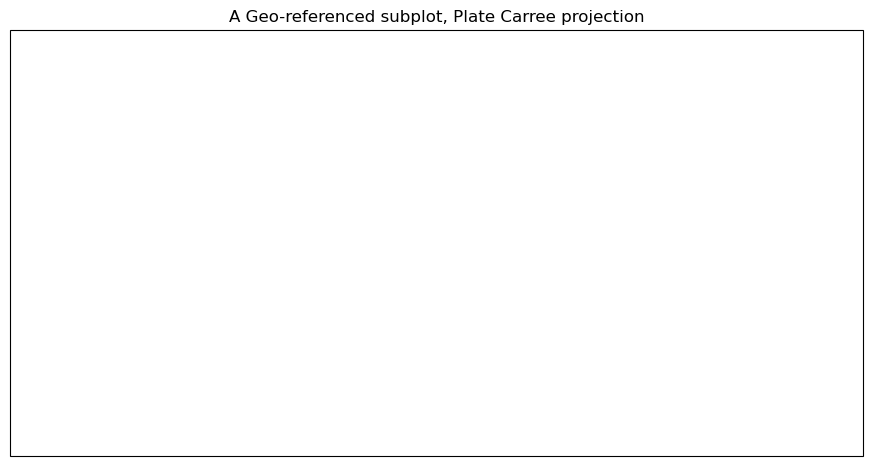

In [ ]:
# create a figure and then a GeoAxes object
fig = plt.figure(figsize=(11, 8.5)) # the figure
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=-75))
ax.set_title("A Geo-referenced subplot, Plate Carree projection");

# this has now been georeferenced, although the plot is until now empty (so no data in there)

One can simply add coastlines to the plot, or shapefiles etc. 
Coastlines are already provided as a method to `ax` in cartopy. 


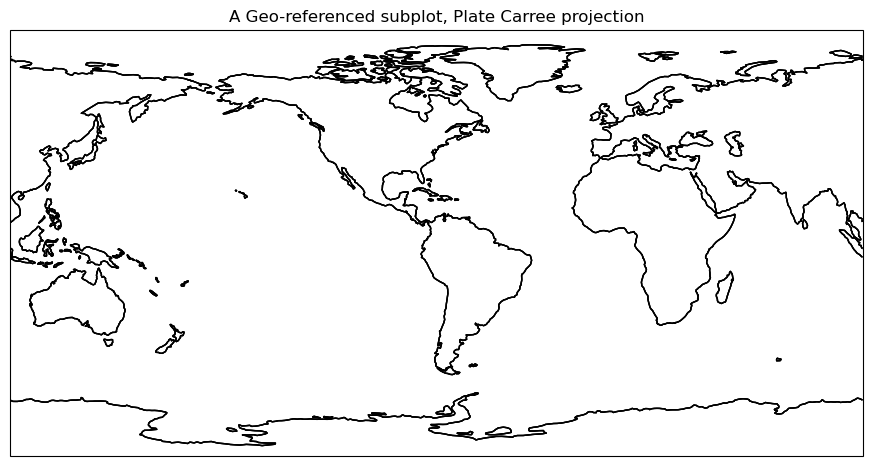

In [5]:
ax.coastlines()
fig # one adds after each other something to the ax object, which can then be displayed by tiping the fig object

via the `features` class, which has been imported as `cfeatures` at the beginning, one can add shapefiles, or also things that are stored on natural earth shapefiles, and the on e simply uses `add_feature` method

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


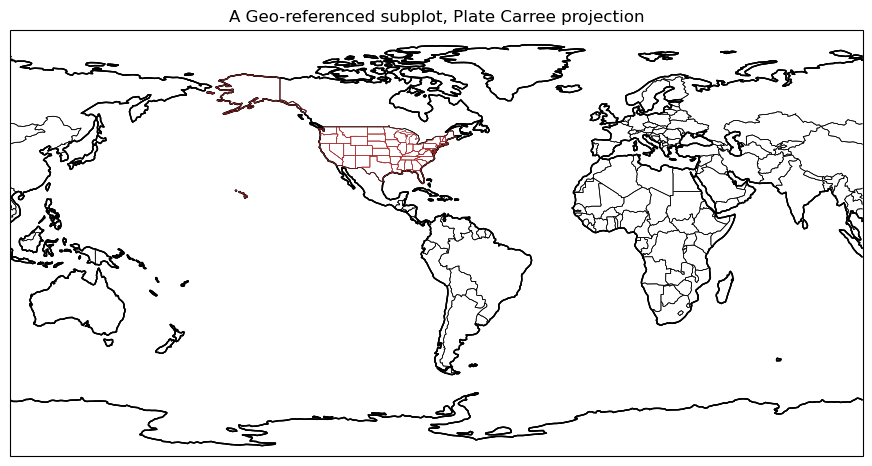

In [7]:
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth = 0.3, edgecolor = "brown")
fig

Now, exploring different map projections:


C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


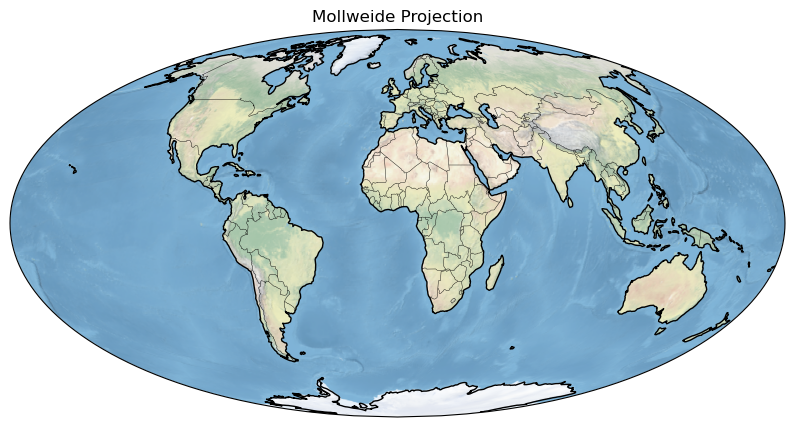

In [19]:
fig = plt.figure(figsize = (10, 8))
projMoll = ccrs.Mollweide(central_longitude=0) # define the projections
ax = plt.subplot(1, 1, 1, projection = projMoll) # one col, one row, first plot, then the projection
ax.set_title("Mollweide Projection")
ax.coastlines()
ax.add_feature(cfeature.BORDERS, color = "black", linewidth = 0.3)
ax.stock_img()

This has now been global maps, but how about regional maps?

This is done by the `set_extent` method

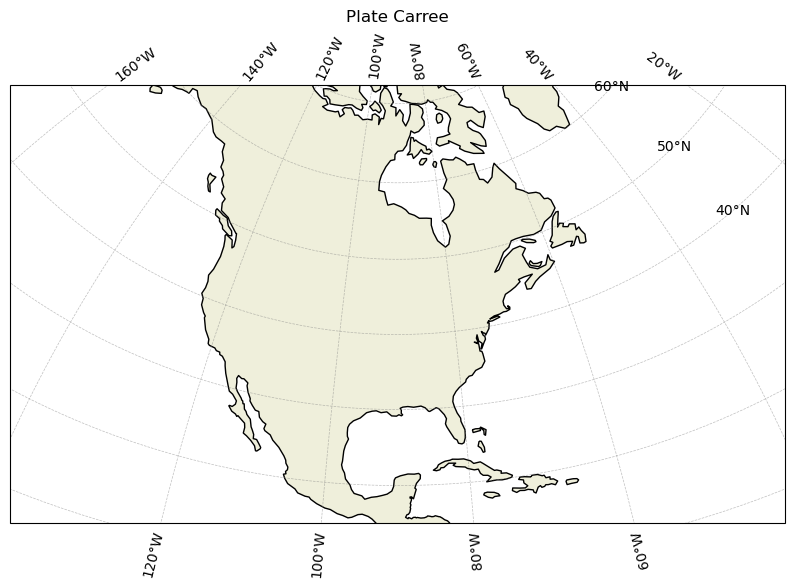

In [32]:
fig = plt.figure(figsize = (10, 8))
ax = plt.subplot(1, 1, 1, projection = ccrs.Stereographic(central_latitude=cLat, central_longitude=cLon))
ax.coastlines()
ax.add_feature(cfeature.LAND, linewidth = 0.5)
ax.set_title("Plate Carree")
ax.gridlines(draw_labels=True, linewidth = 0.5, color = "grey", alpha = 0.5, linestyle = "--")

# now the set_extent: important: this is alwas PlateCarree, which is EPSG 4263 --> this means that the projection statement in the plt.subplot is helping to transform it when its needed
lonW = -140
lonE = -40
latS = 15
latN = 65
cLat = (latN+latS)/2
cLon = (lonW+lonE)/2
res = "110m"
projPC = ccrs.PlateCarree()

ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
plt.show()